In [ ]:
##Project Overview

#This project analyzes the efficiency of betting markets in college football using historical game data
#The goal is to evaluate whether the betting spread accurately predicts game outcomes
#The analysis focuses on cover rates, prediction errors, and the relationship between predicted and actual results

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("cfb_cleaned_data.csv")

In [10]:
df.head()

,season,week,home_team,away_team,home_score,away_score,spread,over_under,home_moneyline,away_moneyline,actual_margin,total_points,home_covered,over_hit,spread_error
0,2020,11,Florida,Arkansas,63,35,-17.0,62.0,NaN,NaN,28,98,True,True,45.0
1,2020,12,Air Force,New Mexico,28,0,-8.0,55.5,NaN,NaN,28,28,True,False,36.0
2,2020,12,Alabama,Kentucky,63,3,-31.5,57.5,NaN,NaN,60,66,True,True,91.5
3,2020,12,Ohio State,Indiana,42,35,-21.0,67.5,NaN,NaN,7,77,True,True,28.0
4,2020,12,Arkansas,LSU,24,27,1.5,65.0,NaN,NaN,-3,51,False,False,-4.5


In [11]:
df.shape

(2603, 15)

In [12]:
df.columns

Index(['season', 'week', 'home_team', 'away_team', 'home_score', 'away_score',
       'spread', 'over_under', 'home_moneyline', 'away_moneyline',
       'actual_margin', 'total_points', 'home_covered', 'over_hit',
       'spread_error'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2603 entries, 0 to 2602
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          2603 non-null   int64  
 1   week            2603 non-null   int64  
 2   home_team       2603 non-null   str    
 3   away_team       2603 non-null   str    
 4   home_score      2603 non-null   int64  
 5   away_score      2603 non-null   int64  
 6   spread          2603 non-null   float64
 7   over_under      2603 non-null   float64
 8   home_moneyline  0 non-null      float64
 9   away_moneyline  0 non-null      float64
 10  actual_margin   2603 non-null   int64  
 11  total_points    2603 non-null   int64  
 12  home_covered    2603 non-null   bool   
 13  over_hit        2603 non-null   bool   
 14  spread_error    2603 non-null   float64
dtypes: bool(2), float64(5), int64(6), str(2)
memory usage: 319.2 KB


In [14]:
cover_rate = df["home_covered"].mean()
print("Home cover rate:", cover_rate)

Home cover rate: 0.6219746446407991


In [16]:
##Home Team Cover Rate

#The home team covers the spread approximately 62% of the time
#In an efficient betting market this value would be expected to be close to 50%
#This suggests a possible bias where home teams outperform market expectations more often than predicted

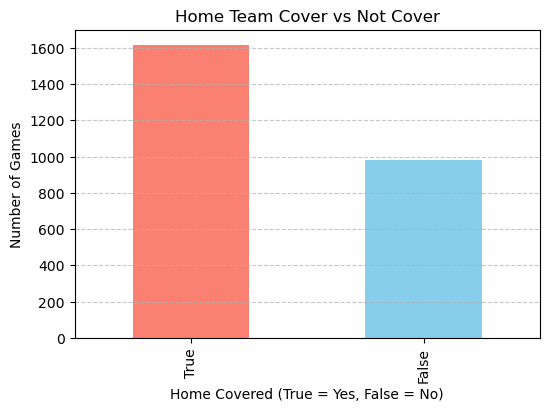

In [33]:
plt.figure(figsize=(6,4))

cover_counts = df["home_covered"].value_counts()

cover_counts.plot(kind="bar", color=["salmon", "skyblue"])

plt.title("Home Team Cover vs Not Cover", fontsize=12)
plt.xlabel("Home Covered (True = Yes, False = No)")
plt.ylabel("Number of Games")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [18]:
df["spread_error"].mean()

np.float64(11.816173645793315)

In [ ]:
##Prediction Error Analysis

#The average spread error is approximately 11.8 since spread error is calculated as actual margin minus the predicted spread a positive value means the home team performs better than expected
#This suggests that the betting market tends to underestimate home teams on average this finding is consistent with the earlier result that home teams cover the spread about 62% of the time

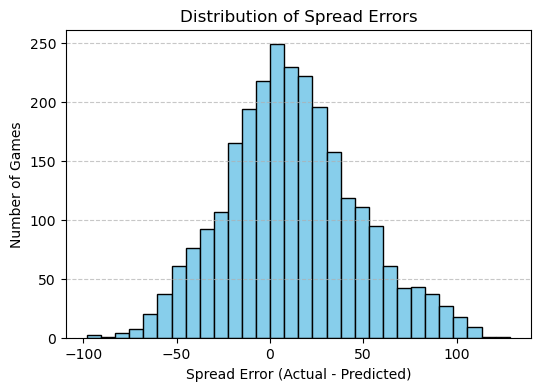

In [34]:
plt.figure(figsize=(6,4))

df["spread_error"].plot(kind="hist", bins=30, color="skyblue", edgecolor="black")

plt.title("Distribution of Spread Errors", fontsize=12)
plt.xlabel("Spread Error (Actual - Predicted)")
plt.ylabel("Number of Games")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [22]:
##Distribution of Prediction Errors

#The distribution of prediction errors is slightly shifted to the right indicating that actual game outcomes tend to be higher than the predicted spreads

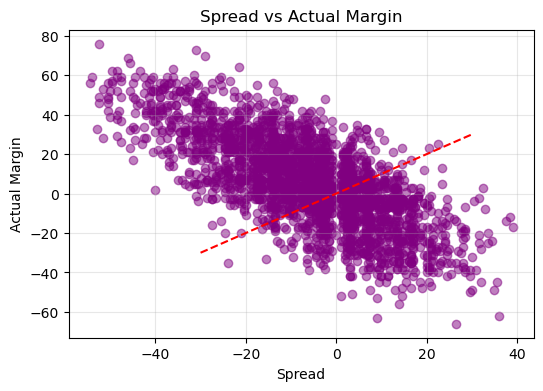

In [36]:
plt.figure(figsize=(6,4))

plt.scatter(df["spread"], df["actual_margin"], alpha=0.5, color="purple")

plt.title("Spread vs Actual Margin", fontsize=12)
plt.xlabel("Spread")
plt.ylabel("Actual Margin")

plt.grid(alpha=0.3)

plt.plot([-30, 30], [-30, 30], color="red", linestyle="--")

plt.show()

In [ ]:
##Spread vs Actual Margin

#The betting spread generally predicts the direction of game outcomes but the wide dispersion of points shows that its accuracy is limited

In [26]:
def spread_group(spread):
    if spread <= -14:
        return "Big Home Favorite"
    elif spread < 0:
        return "Small Home Favorite"
    elif spread == 0:
        return "Even Game"
    elif spread < 14:
        return "Small Home Underdog"
    else:
        return "Big Home Underdog"

df["spread_group"] = df["spread"].apply(spread_group)

In [27]:
group_cover = df.groupby("spread_group")["home_covered"].mean()
print(group_cover)

spread_group
Big Home Favorite      0.992188
Big Home Underdog      0.020080
Even Game              0.666667
Small Home Favorite    0.786530
Small Home Underdog    0.227723
Name: home_covered, dtype: float64


In [32]:
##Cover Rate by Spread Group

#The cover rate varies across spread groups with big home favorites covering most often and big home underdogs rarely covering Smaller favorites and underdogs fall in between. 
#This pattern suggests that the spread reflects differences in team strength and expected outcomes

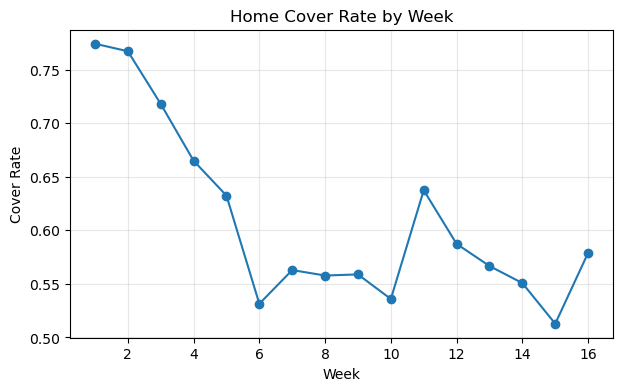

In [38]:
week_cover = df.groupby("week")["home_covered"].mean()

plt.figure(figsize=(7,4))
week_cover.plot(marker="o")

plt.title("Home Cover Rate by Week")
plt.xlabel("Week")
plt.ylabel("Cover Rate")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
##Cover Rate by Week

#The cover rate varies across weeks but does not show a clear consistent trend.
#This suggests that the home team cover pattern is not limited to only one specific part of the season.

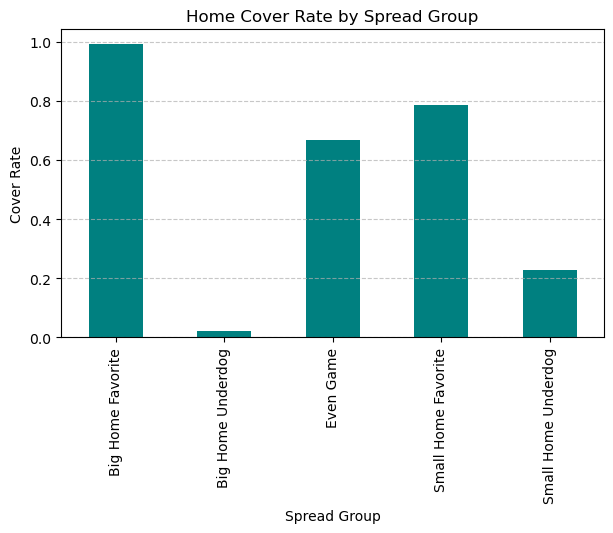

In [37]:
plt.figure(figsize=(7,4))

group_cover.plot(kind="bar", color="teal")

plt.title("Home Cover Rate by Spread Group", fontsize=12)
plt.xlabel("Spread Group")
plt.ylabel("Cover Rate")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [ ]:
##Conclusion

#The betting spread helps predict game outcomes but is not perfectly accurate there is some evidence of bias as home teams cover more often than expected 
#Overall the market is informative but not fully efficient.
